## Abstract 

The HANDMI4 dataset (Mongelli & Menolotto, 2023), containing motion tracking data of 20 healthy subjects, is used for the analysis. The dataset is captured using two distinct technologies - wearable IMU and camera-based systems. The data offers insight into research on hand movements and mobility. Only glove data is used for the analysis. In the feature extraction process, time-domain features such as mean, maximum and values and standard deviation values are extracted. Various frequency-domain features are extracted before dividing the feature-extracted dataset into 80% for training and 20% for testing. Three classification algorithms - random forest, support vector machine and k-nearest neighbours were implemented. With 89.22%, random forest produced the highest classification accuracy on the test data. After applying two feature reduction techniques - principal component analysis (PCA) and random forest feature importance on the random forest model - the accuracy was reduced by implementing the former and increased by 2% by implementing the latter.

In [1]:
#importing relevant libraries for the analysis, visualisation and implementation
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel
from scipy import signal, fftpack
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
##---------------------------------------------------------------------------------------------##

# Directory paths
industry_dir = r'C:\Users\mizga\Desktop\Industry'
nan_count_dir = r'C:\Users\mizga\Desktop\NAN_COUNT\industry'

# Iterate through subject folders in the dataset directory
for subject_folder in os.listdir(industry_dir):
    # Check if the path is a directory to avoid errors
    if os.path.isdir(os.path.join(industry_dir, subject_folder)):
        # Read and process data files for each subject
        for file_name in os.listdir(os.path.join(industry_dir, subject_folder)):
            if file_name.endswith('.csv'):
                file_path = os.path.join(industry_dir, subject_folder, file_name)
                data = pd.read_csv(file_path)
                
                # Example processing: Print the first few rows of the dataframe
                print(f'Data from file {file_name} for {subject_folder}:')
                print(data.head())

        # Construct the path to the NaN count file for the subject
        nan_count_file = os.path.join(nan_count_dir, subject_folder + '.csv')
        
        # Check if the NaN count file exists before attempting to read it
        if os.path.exists(nan_count_file):
            nan_count_df = pd.read_csv(nan_count_file)
            
            # Print NaN counts for each column
            print(f'NaN counts for {subject_folder}:')
            print(nan_count_df.sum())
        else:
            print(f"No NaN count file found for {subject_folder}")


Data from file 000GLVIND0100.csv for sub01:
   Index_Prox_Acc_X  Index_Prox_Acc_Y  Index_Prox_Acc_Z  Index_Inter_Acc_X  \
0          0.549683         -0.019897         -0.837158           0.274780   
1          0.553223         -0.022339         -0.840210           0.277100   
2          0.556519         -0.025513         -0.844604           0.280151   
3          0.558350         -0.033447         -0.851562           0.280273   
4          0.556274         -0.037964         -0.853027           0.279907   

   Index_Inter_Acc_Y  Index_Inter_Acc_Z  Middle_Prox_Acc_X  Middle_Prox_Acc_Y  \
0           0.267090          -0.921631           0.476807           0.203125   
1           0.264893          -0.929199           0.478149           0.199707   
2           0.257690          -0.941528           0.477661           0.194702   
3           0.252319          -0.945312           0.475830           0.193604   
4           0.245728          -0.946533           0.473877           0.191284   



Data from file 000GLVIND0201.csv for sub01:
   Index_Prox_Acc_X  Index_Prox_Acc_Y  Index_Prox_Acc_Z  Index_Inter_Acc_X  \
0         -0.251221          0.774414          0.548462          -0.573364   
1         -0.240234          0.771240          0.544678          -0.545410   
2         -0.229492          0.767822          0.541504          -0.533325   
3         -0.216187          0.757935          0.539551          -0.524170   
4         -0.213989          0.750732          0.538696          -0.518921   

   Index_Inter_Acc_Y  Index_Inter_Acc_Z  Middle_Prox_Acc_X  Middle_Prox_Acc_Y  \
0           0.625366           0.501831          -0.371948           0.786743   
1           0.612915           0.484863          -0.370728           0.782349   
2           0.606567           0.476929          -0.370483           0.778564   
3           0.600708           0.472168          -0.369873           0.776123   
4           0.595215           0.471313          -0.368408           0.773682   



Data from file 000GLVIND0401.csv for sub01:
   Index_Prox_Acc_X  Index_Prox_Acc_Y  Index_Prox_Acc_Z  Index_Inter_Acc_X  \
0         -0.192749          0.491333          0.738525          -0.431641   
1         -0.182251          0.490967          0.742798          -0.426880   
2         -0.183716          0.471436          0.750610          -0.435181   
3         -0.187744          0.421631          0.778076          -0.464233   
4         -0.185913          0.396606          0.793213          -0.475098   

   Index_Inter_Acc_Y  Index_Inter_Acc_Z  Middle_Prox_Acc_X  Middle_Prox_Acc_Y  \
0           0.579102           0.468140          -0.437500           0.450195   
1           0.563354           0.465698          -0.452637           0.465332   
2           0.543091           0.478394          -0.445801           0.462036   
3           0.473022           0.512939          -0.441284           0.459106   
4           0.437134           0.528809          -0.413696           0.411987   



Data from file 001GLVIND0102.csv for sub02:
   Index_Prox_Acc_X  Index_Prox_Acc_Y  Index_Prox_Acc_Z  Index_Inter_Acc_X  \
0         -0.390381          0.386230          0.869385          -0.837036   
1         -0.399536          0.380371          0.868164          -0.840576   
2         -0.409058          0.372803          0.873169          -0.861938   
3         -0.423340          0.366211          0.886353          -0.890869   
4         -0.455078          0.364624          0.945557          -0.929932   

   Index_Inter_Acc_Y  Index_Inter_Acc_Z  Middle_Prox_Acc_X  Middle_Prox_Acc_Y  \
0           0.293701           0.540283          -0.460327           0.553711   
1           0.285522           0.529907          -0.476807           0.540039   
2           0.273560           0.528931          -0.512207           0.504028   
3           0.263428           0.557739          -0.527954           0.497559   
4           0.260498           0.605957          -0.537964           0.505005   



Data from file 001GLVIND0300.csv for sub02:
   Index_Prox_Acc_X  Index_Prox_Acc_Y  Index_Prox_Acc_Z  Index_Inter_Acc_X  \
0         -0.339233          0.206909          0.896973          -0.805908   
1         -0.338013          0.202515          0.898804          -0.804932   
2         -0.337646          0.200562          0.899414          -0.803955   
3         -0.337036          0.199829          0.900879          -0.804443   
4         -0.337036          0.199219          0.902100          -0.805298   

   Index_Inter_Acc_Y  Index_Inter_Acc_Z  Middle_Prox_Acc_X  Middle_Prox_Acc_Y  \
0           0.071411           0.507202          -0.413208           0.363159   
1           0.070557           0.507446          -0.412720           0.360718   
2           0.070190           0.508423          -0.412354           0.359619   
3           0.070679           0.509399          -0.412476           0.360474   
4           0.071289           0.510010          -0.412476           0.362671   



...

Data from file 018GLVIND0101.csv for sub19:
   Index_Prox_Acc_X  Index_Prox_Acc_Y  Index_Prox_Acc_Z  Index_Inter_Acc_X  \
0         -0.451538          0.194824          0.920654          -0.554932   
1         -0.496460          0.188599          0.978394          -0.621094   
2         -0.573364          0.178101          1.085815          -0.736084   
3         -0.599487          0.175049          1.128296          -0.774902   
4         -0.616455          0.173340          1.156738          -0.800415   

   Index_Inter_Acc_Y  Index_Inter_Acc_Z  Middle_Prox_Acc_X  Middle_Prox_Acc_Y  \
0           0.392944           0.724365          -0.478882          -0.021606   
1           0.385864           0.820557          -0.546997          -0.025269   
2           0.400879           1.000122          -0.575562          -0.028198   
3           0.420044           1.064697          -0.598022          -0.034180   
4           0.440552           1.107544          -0.612305          -0.040527   



Data from file 018GLVIND0300.csv for sub19:
   Index_Prox_Acc_X  Index_Prox_Acc_Y  Index_Prox_Acc_Z  Index_Inter_Acc_X  \
0         -0.421875          0.361450          0.743042          -0.673462   
1         -0.458496          0.246582          0.771362          -0.711792   
2         -0.468750          0.151001          0.794556          -0.734863   
3         -0.473145          0.042969          0.821045          -0.757202   
4         -0.473755         -0.065918          0.848633          -0.778809   

   Index_Inter_Acc_Y  Index_Inter_Acc_Z  Middle_Prox_Acc_X  Middle_Prox_Acc_Y  \
0           0.403931           0.365601          -0.326538           0.260376   
1           0.271973           0.352051          -0.333862           0.190308   
2           0.160278           0.375122          -0.336060           0.094971   
3           0.029785           0.412476          -0.333374          -0.010620   
4          -0.104980           0.458008          -0.311646          -0.197754   



Data from file 018GLVIND0401.csv for sub19:
   Index_Prox_Acc_X  Index_Prox_Acc_Y  Index_Prox_Acc_Z  Index_Inter_Acc_X  \
0         -0.147705          0.321289          0.918701           0.223389   
1         -0.159790          0.317871          0.923462           0.215332   
2         -0.183838          0.319458          0.935791           0.200439   
3         -0.190186          0.324097          0.937988           0.196533   
4         -0.191895          0.332886          0.935547           0.192993   

   Index_Inter_Acc_Y  Index_Inter_Acc_Z  Middle_Prox_Acc_X  Middle_Prox_Acc_Y  \
0           0.741699           0.673462          -0.370239           0.291138   
1           0.745850           0.680176          -0.374878           0.296753   
2           0.749146           0.698730          -0.387939           0.328125   
3           0.748047           0.704590          -0.391479           0.343506   
4           0.749634           0.705322          -0.393188           0.354004   



Data from file 019GLVIND0200.csv for sub20:
   Index_Prox_Acc_X  Index_Prox_Acc_Y  Index_Prox_Acc_Z  Index_Inter_Acc_X  \
0         -0.553955          0.018799          0.838013          -0.858887   
1         -0.550171          0.015503          0.835815          -0.848022   
2         -0.548950          0.011719          0.835083          -0.846313   
3         -0.548950          0.008179          0.837280          -0.848267   
4         -0.556885          0.002930          0.852417          -0.855347   

   Index_Inter_Acc_Y  Index_Inter_Acc_Z  Middle_Prox_Acc_X  Middle_Prox_Acc_Y  \
0           0.035400           0.511353          -0.549561          -0.155396   
1           0.028931           0.496460          -0.547241          -0.156250   
2           0.026001           0.491577          -0.546021          -0.157959   
3           0.024414           0.494385          -0.550293          -0.161865   
4           0.024170           0.503662          -0.553711          -0.165283   



Data from file 019GLVIND0302.csv for sub20:
   Index_Prox_Acc_X  Index_Prox_Acc_Y  Index_Prox_Acc_Z  Index_Inter_Acc_X  \
0          0.001953          0.876587          0.416626          -0.193604   
1         -0.019775          0.922852          0.411987          -0.209717   
2         -0.052979          1.010864          0.393066          -0.222656   
3         -0.063232          1.050293          0.380981          -0.220703   
4         -0.070679          1.084595          0.369141          -0.216797   

   Index_Inter_Acc_Y  Index_Inter_Acc_Z  Middle_Prox_Acc_X  Middle_Prox_Acc_Y  \
0           0.912231           0.280029          -0.167847           0.825562   
1           0.959595           0.265503          -0.191162           0.867798   
2           1.050049           0.215698          -0.228638           0.947754   
3           1.087524           0.183838          -0.242920           0.982788   
4           1.116455           0.153198          -0.255493           1.013062   



## Visual Exploration of one data feature
The accelerometer data of x, y and z axes of the proximal region of the index finger is visualised below. X-axis denotes acceleration in the horizontal direction, y-axis denotes acceleration in the vertical direction and z-axis denotes acceleration in depth direction (from simple graphical understanding of the three axes). It helps in analysing the hand movements.


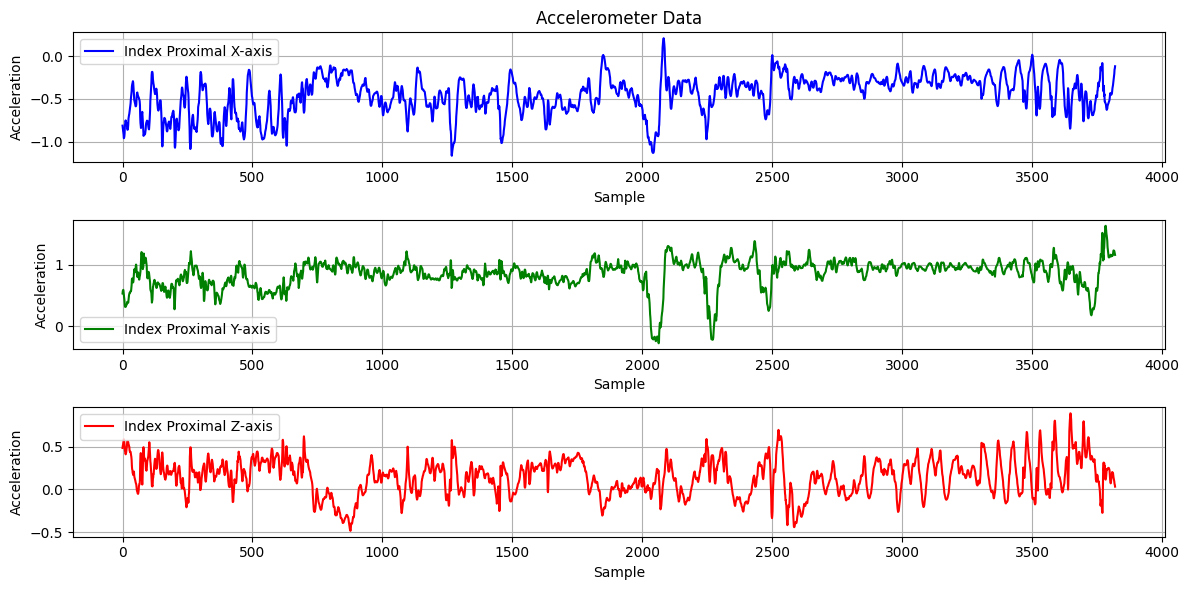

In [2]:
# Plot accelerometer data for X, Y, and Z axes
plt.figure(figsize=(12, 6))

# Plot X-axis data
plt.subplot(3, 1, 1)
plt.plot(data.index, data['Index_Prox_Acc_X'], label='Index Proximal X-axis', color='b')
plt.title('Accelerometer Data')
plt.xlabel('Sample')
plt.ylabel('Acceleration')
plt.legend()
plt.grid(True)

# Plot Y-axis data
plt.subplot(3, 1, 2)
plt.plot(data.index, data['Index_Prox_Acc_Y'], label='Index Proximal Y-axis', color='g')
plt.xlabel('Sample')
plt.ylabel('Acceleration')
plt.legend()
plt.grid(True)

# Plot Z-axis data
plt.subplot(3, 1, 3)
plt.plot(data.index, data['Index_Prox_Acc_Z'], label='Index Proximal Z-axis', color='r')
plt.xlabel('Sample')
plt.ylabel('Acceleration')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [3]:
# Constants
WINDOW_SIZE = 128  # Size of the window for segmenting the data
OVERLAP_SIZE = 64  # Overlapping window size
SAMPLE_RATE = 50  # Sample rate of the data (50 Hz is an example)

# Directory Path
data_dir = r'C:\Users\mizga\Desktop\Industry'

# Helper function to compute frequency domain features
def compute_frequency_features(segment):
    # Ensure segment is a numpy array for FFT processing
    segment_array = np.asarray(segment)
    fft_vals = np.abs(fftpack.fft(segment_array))
    fft_freq = fftpack.fftfreq(len(segment_array), 1.0/SAMPLE_RATE)
    return fft_vals[:len(segment_array) // 2], fft_freq[:len(segment_array) // 2]  # Return only positive frequencies

# Iterate through subject folders in the dataset directory
features = []
labels = []
for subject_folder in os.listdir(data_dir):
    subject_path = os.path.join(data_dir, subject_folder)
    if os.path.isdir(subject_path):
        for file_name in os.listdir(subject_path):
            if file_name.endswith('.csv'):
                # Extract task type and repetition from filename, e.g., "000GLVIND0201.csv"
                task_type = file_name[9:11]  # Assuming '02' in '000GLVIND0201.csv'
                repetition = file_name[11:13]  # Assuming '01' in '000GLVIND0201.csv'

                # Read the data file
                file_path = os.path.join(subject_path, file_name)
                data = pd.read_csv(file_path)

                # Segmenting the data
                for start in range(0, len(data) - WINDOW_SIZE, WINDOW_SIZE - OVERLAP_SIZE):
                    end = start + WINDOW_SIZE
                    segment = data.iloc[start:end]

                    # Time-domain features
                    mean_vals = segment.mean()
                    std_vals = segment.std()
                    max_vals = segment.max()
                    min_vals = segment.min()

                    # Frequency-domain features
                    fft_features = []
                    for column in segment.columns:
                        seg_fft, _ = compute_frequency_features(segment[column].values)
                        fft_features.extend(seg_fft)

                    # Collect all features
                    feature_vector = np.concatenate([mean_vals.values, std_vals.values, max_vals.values, min_vals.values, fft_features])
                    features.append(feature_vector)
                    labels.append(task_type)  # Use task type as the label

# Convert features and labels into a DataFrame
features_df = pd.DataFrame(features)
labels_series = pd.Series(labels)

# Print each subject's DataFrame
print(features_df)
print(labels_series)


          0         1         2         3         4         5         6      \
0      0.525570 -0.037951 -0.855517  0.237305  0.234780 -0.937313  0.451340   
1      0.514625 -0.041608 -0.860478  0.221686  0.227509 -0.941567  0.443976   
2      0.510750 -0.042258 -0.863564  0.218287  0.224515 -0.944286  0.441566   
3      0.521402 -0.044268 -0.857143  0.226934  0.223710 -0.942095  0.448866   
4      0.536447 -0.042821 -0.849304  0.238716  0.225694 -0.938822  0.459551   
...         ...       ...       ...       ...       ...       ...       ...   
12665 -0.291918  0.942734  0.151163 -0.291001  0.925565 -0.179896 -0.300570   
12666 -0.333957  0.948359  0.189777 -0.351396  0.936909 -0.174807 -0.351903   
12667 -0.376816  0.925250  0.255432 -0.431443  0.917299 -0.135341 -0.413460   
12668 -0.425188  0.816976  0.389495 -0.559177  0.814534 -0.038145 -0.493743   
12669 -0.458202  0.702191  0.348565 -0.582684  0.704391 -0.069003 -0.514496   

          7         8         9      ...      13454

### Time and Frequency-domain features are extracted from the given accelerometer data.

- Time-domain features (mean, standard deviation, min and max values) are easier to implement and it is advantageous for practical applications (Cemil, 2016).

- Frequency-domain analysis is crucial in signal processing. Unlike time-domain analysis, which tracks signal changes over time, frequency-domain analysis reveals how a signal's energy disperses across different frequencies. Additionally, it provides insights into the phase shifts needed to reconstruct the original time signal from its frequency components. Fourier transform (FFT) is one of converting signal of frequency sine waves (Mathworks).

- For this analysis, features extracted from both time and frequency domains are used.


In [11]:
num_features = features_df.shape[1]  # Number of columns in the DataFrame
print("Number of features extracted:", num_features)


Number of features extracted: 13464


- In total, 13464 features (time-domain and frequency-domain) were extracted from the given dataset. It is a huge feature space on which to run the subsequent classification models.

In [26]:
# List out the unique labels extracted from the data (task performed labels)
print("Unique Labels:")
print(labels_series.unique())

Unique Labels:
['01' '02' '03' '04' '10' '20' '30' '40']


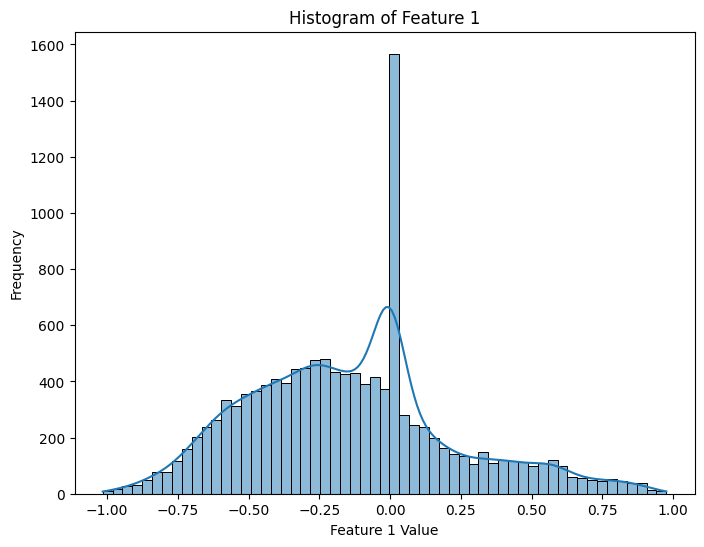

<Figure size 1000x800 with 0 Axes>

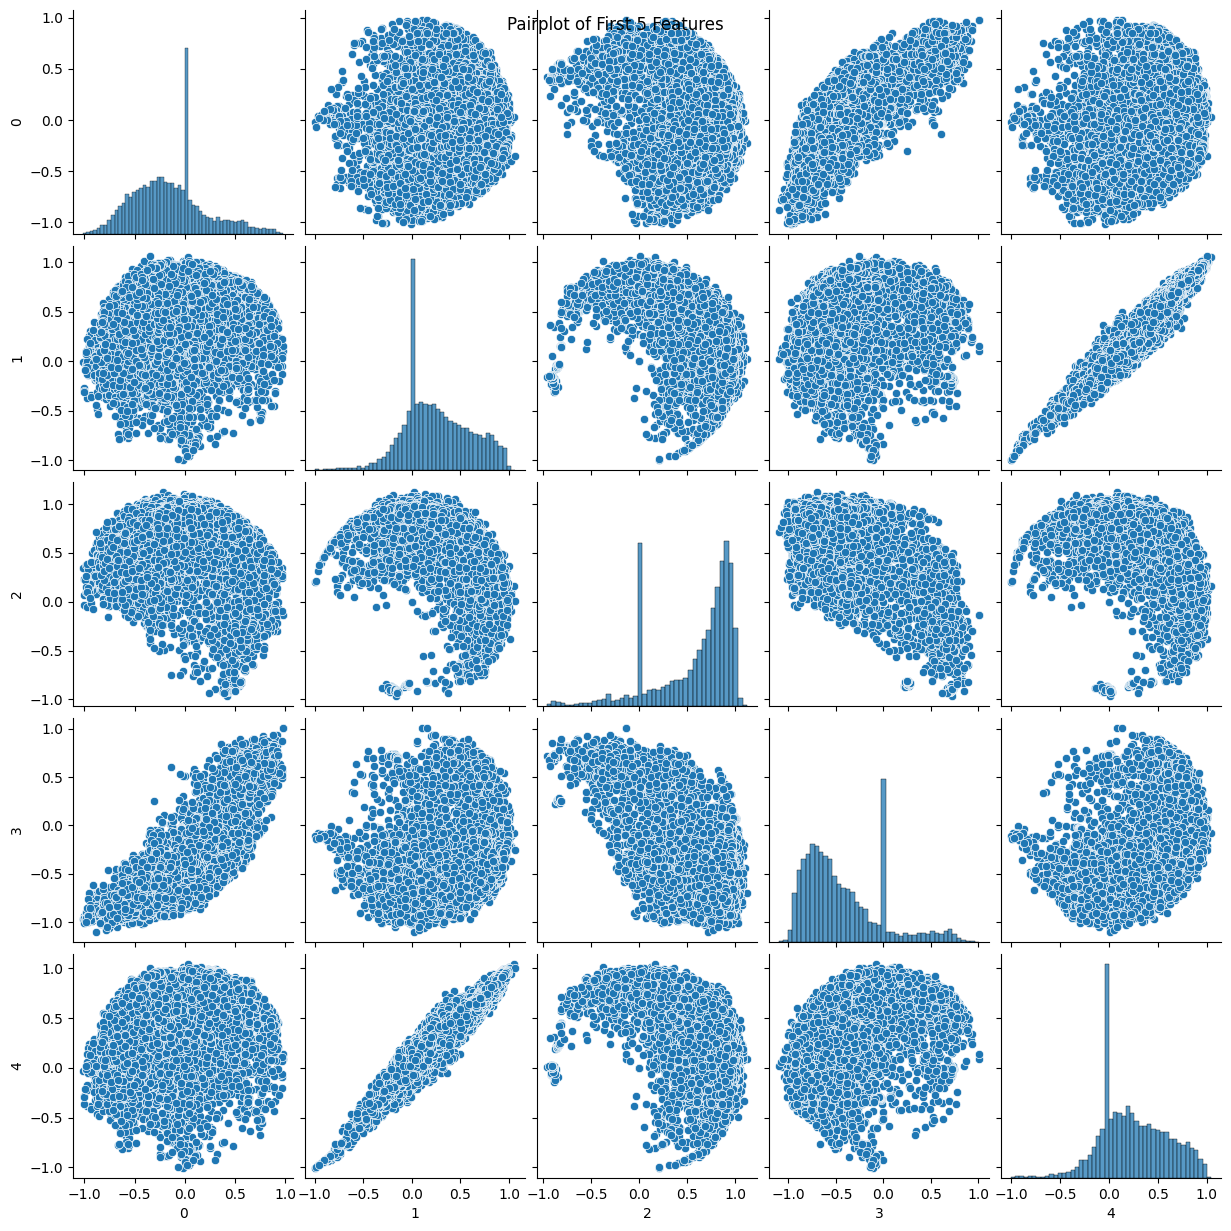

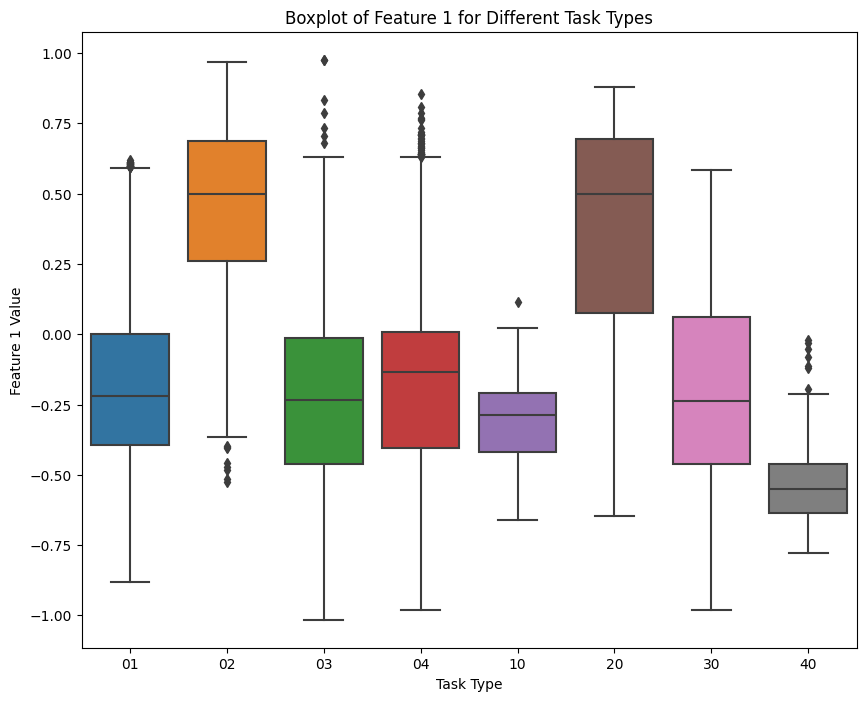

In [28]:
# Histogram of the first feature
plt.figure(figsize=(8, 6))
sns.histplot(features_df[0], kde=True)
plt.title("Histogram of Feature 1")
plt.xlabel("Feature 1 Value")
plt.ylabel("Frequency")
plt.show()

# Pairplot of the first few features (correlation plot of first feature with four other features)
plt.figure(figsize=(10, 8))
sns.pairplot(features_df.iloc[:, :5])
plt.suptitle("Pairplot of First 5 Features")
plt.show()

# Boxplot of the first feature for different task types
plt.figure(figsize=(10, 8))
sns.boxplot(x=labels_series, y=features_df[0])
plt.title("Boxplot of Feature 1 for Different Task Types")
plt.xlabel("Task Type")
plt.ylabel("Feature 1 Value")
plt.show()

# Data Split and Imputation for Classification Models

80% of the data is kept for training the model with 'features_df' being the independent variables and 'labels_Series' being the dependent output variables. To deal with the NA values, data imputation with mean is performed. Mean imputation, a common imputation method, substitutes missing values with the mean of observed values within the same column. It maintains the data's mean, and doesn't introduce extra variability (Bhujade et al, 2023). 

## Random Forest 
The first classification model applied to the splitted and imputed data is the Random Forest (RF). RF is quite similar to the decision tree but adds additional randomness to the model. RF employs a technique where, instead of searching for the most important feature while splitting a node, it randomly selects a subset of features and searches for the best feature within this subset. This generally leads to improved model performance (Donges and Whitfield, 2024).

In [7]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features_df, labels_series, test_size=0.2, random_state=42)

# Impute missing values with mean
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Train the classifier with the imputed data
classifier_rf = RandomForestClassifier(n_estimators=100, random_state=42)
classifier_rf.fit(X_train_imputed, y_train)


C:\Users\mizga\anaconda3\Lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: [  183   381   579   777 12504 12505 12506 12507 12508 12509 12510 12511
 12512 12513 12514 12515 12516 12517 12518 12519 12520 12521 12522 12523
 12524 12525 12526 12527 12528 12529 12530 12531 12532 12533 12534 12535
 12536 12537 12538 12539 12540 12541 12542 12543 12544 12545 12546 12547
 12548 12549 12550 12551 12552 12553 12554 12555 12556 12557 12558 12559
 12560 12561 12562 12563 12564 12565 12566 12567]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
C:\Users\mizga\anaconda3\Lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: [  183   381   579   777 12504 12505 12506 12507 12508 12509 12510 12511
 12512 12513 12514 12515 12516 12517 12518 12519 12520 12521 12522 12523
 12524 12525 12526 12527 12528 12529 12530 12531 12532 12533 12534 12535
 12536

RandomForestClassifier(random_state=42)

In [8]:
# Make predictions
y_pred = classifier_rf.predict(X_test_imputed)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8922651933701657


- Although not perfect, RF is able to get an accuracy close to 90%.

## Support Vector Machine (SVM)
SVM tackles complex classification, outlier detection and regression problems (Kanade, 2022). One of the advantages of SVM is that it is able to handle high-dimensional dataset for complex classification models (Geeks for Geeks, 2023). For that reason, SVM classification was applied on the splitted and imputed data.



In [ ]:
# Train the classifier with the imputed data
classifier = SVC(kernel='linear', random_state=42)
classifier.fit(X_train_imputed, y_train)

In [19]:
# Make predictions
y_pred = classifier.predict(X_test_imputed)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7209944751381215


- SVM with linear kernel produced a meagre accuracy level of 72% on the test data. Not good enough, especially when compared to the Random Forest model.

## K-nearest neighbours (KNN)

KNN is a non-parametric, supervised learning algorithm that utilizes proximity to classify or predict the grouping of data points. It is method for classification and regression tasks in machine learning and is one of the easier to implement (IBM). 

In [9]:
#Train the classifier with the imputed data
classifier_knn = KNeighborsClassifier(n_neighbors=5)
classifier_knn.fit(X_train_imputed, y_train)

KNeighborsClassifier()

In [10]:
# Make predictions
y_pred = classifier_knn.predict(X_test_imputed)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7426992896606156


 - Although KNN performs better than SVM, with 74.2% accuracy, it is still well below what Random Forest produced. 
 
 Hence, to apply for feature reduction process, random forest model will be the forefront. After application of two feature reduction techniques, the new features will be applied on the random forest classifier to find out if the accuracy levels has increased past the 89% mark.

## Principal Component Analysis (PCA)

PCA is a linear dimensionality reduction method that converts correlated features in high-dimensional space into uncorrelated features in a lower-dimensional space, known as principal components. In general, PCA aims to maximize variance explained by the first component (Parte, 2020). By preserving the 95% of the variance, PCA is applied and then random forest is trained to see what the accuracy score is like on the test data.

In [13]:
# Feature Reduction using PCA
pca = PCA(n_components=0.95)  # Preserve 95% of variance
X_train_pca = pca.fit_transform(X_train_imputed)
X_test_pca = pca.transform(X_test_imputed)

# Train the Random Forest model with PCA-transformed data
classifier_rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
classifier_rf_pca.fit(X_train_pca, y_train)

# Evaluate the model
accuracy_pca = accuracy_score(y_test, classifier_rf_pca.predict(X_test_pca))
print("Accuracy after PCA feature reduction:", accuracy_pca)



Accuracy after PCA feature reduction: 0.6404893449092344


One of the disadvantages of PCA is that in reducing features, it can lose some information of the data (Analytics Vidhya, 2024). That could be one of the main reasons why the random forest classification accuracy reduced by 25% after the application of PCA.

In [20]:
# Get the number of features after PCA feature reduction
num_features_after_pca = pca.n_components_

print("Number of features after PCA feature reduction:", num_features_after_pca)


Number of features after PCA feature reduction: 103


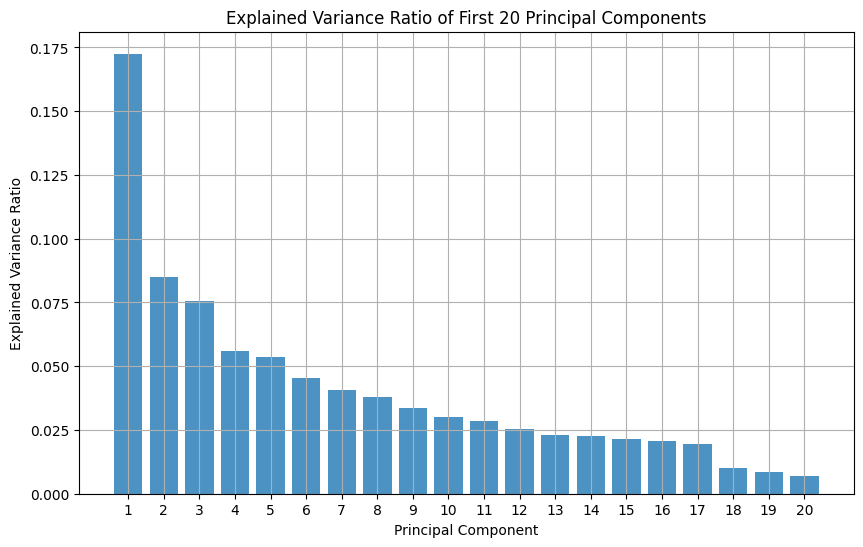

In [18]:
# Plot the explained variance ratio for the first 20 principal components
plt.figure(figsize=(10, 6))
plt.bar(range(1, 21), explained_variance_ratio[:20], alpha=0.8)  # Limit to the first 20 components
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio of First 20 Principal Components')
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()


- Above is the plot of variance ratio of the first 20 principal components (out of the 103 that were extracted after PCA implementation).

## Random Forest (RF) Feature Importance

In a random forest, each tree assesses feature importance based on its contribution to leaf purity. This process evaluates how much a feature enhances the clarity of leaf classifications. The aggregate importance across all trees is normalized to 1 (Malato, 2021).

In [14]:
# Feature Selection using Random Forest Importance
feature_selection = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42))
X_train_selected = feature_selection.fit_transform(X_train_imputed, y_train)
X_test_selected = feature_selection.transform(X_test_imputed)

# Train the Random Forest model with selected features
classifier_rf_selected = RandomForestClassifier(n_estimators=100, random_state=42)
classifier_rf_selected.fit(X_train_selected, y_train)

# Evaluate the model
accuracy_selected = accuracy_score(y_test, classifier_rf_selected.predict(X_test_selected))
print("Accuracy after feature selection:", accuracy_selected)

Accuracy after feature selection: 0.919889502762431


In [21]:
# Get the boolean mask of selected features
selected_features_mask = feature_selection.get_support()

# Count the number of selected features
num_selected_features = np.sum(selected_features_mask)

print("Number of features after feature selection using Random Forest Importance:", num_selected_features)


Number of features after feature selection using Random Forest Importance: 2445


The accuracy of the random forest model got increased by 2% to 91% after applying features that got reduced by RF Feature importance. It is an improvement to reduce the number of features and increasing the accuracy of the model. Features with 20 most importance is plotted below.

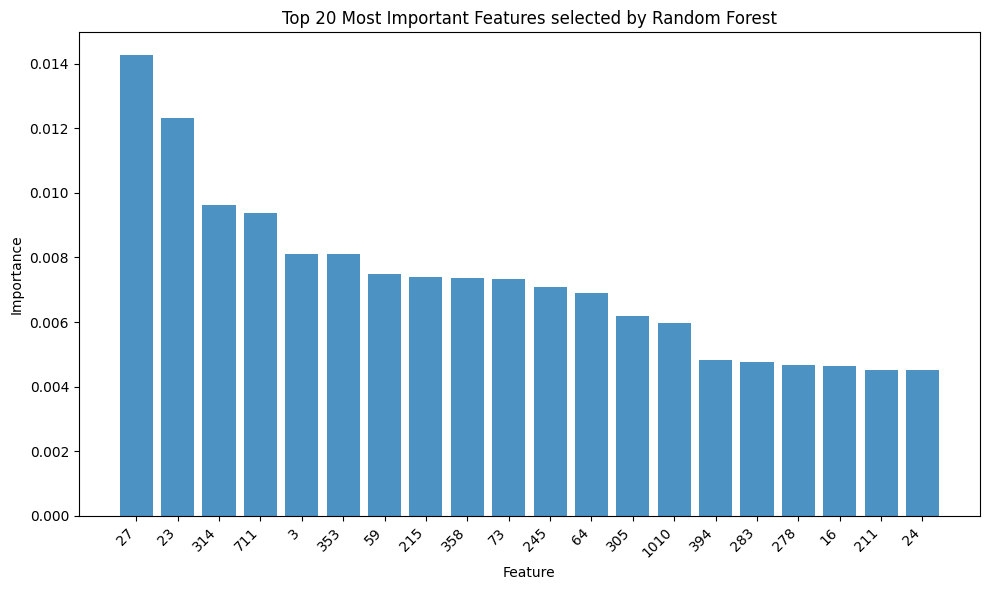

In [19]:
# Get feature importances from the trained Random Forest model
feature_importances = classifier_rf_selected.feature_importances_

# Get indices of the top N most important features (e.g., top 20)
top_n_indices = feature_importances.argsort()[-20:][::-1]  # Change 20 to desired number of features

# Get the names of the top N most important features
top_n_features = features_df.columns[top_n_indices]

# Plot the top N most important features
plt.figure(figsize=(10, 6))
plt.bar(range(len(top_n_features)), feature_importances[top_n_indices], alpha=0.8)
plt.xticks(range(len(top_n_features)), top_n_features, rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Top 20 Most Important Features selected by Random Forest')
plt.tight_layout()
plt.show()


## Conclusion and Future Work

After extracting features based on time and frequency domain, three classification models were applied to the HANDMI4 dataset that aims to understand the hand movements of 20 healthy subjects. Out of the three classification models, random forest produced the highest accuracy with 89%. After applying two feature reduction techniques - PCA and RF Importance, the accuracy of the random forest model increased to 91%. 

In future work, more classification models can be applied to increase the accuracy. Better feature reduction methods can be put in place as well. Can introduce classification techniques like gradient boosting and such and see how the results are. 

## References

- Francesca Mongelli, Matteo Menolotto, 2023. HANDMI4 (HAND Motion capture data for Industry 4.0). Available at: https://dx.doi.org/10.21227/c6t8-ge47.

- www.linkedin.com. (n.d.). What are the pros and cons of different imputation methods in python? [online] Available at: https://www.linkedin.com/advice/1/what-pros-cons-different-imputation-methods-python#:~:text=Mean%20imputation%20is%20one%20of

- Donges, N. (2021). _Random Forest: a Complete Guide for Machine Learning_. [online] Built in. Available at: https://builtin.com/data-science/random-forest-algorithm.

- Kanade, V. (2022). _What Is a Support Vector Machine? Working, Types, and Examples_. [online] Spiceworks. Available at: https://www.spiceworks.com/tech/big-data/articles/what-is-support-vector-machine/#:~:text=A%20support%20vector%20machine%20(SVM)%20is%20a%20machine%20learning%20algorithm.

- geeksforgeeks (2020). _Support Vector Machine in Machine Learning_. [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/support-vector-machine-in-machine-learning/.

- www.ibm.com. (2024). _What is the k-nearest neighbors algorithm? _| IBM. [online] Available at: https://www.ibm.com/topics/knn#:~:text=The%20k%2Dnearest%20neighbors%20(KNN.)

- Parte, K. (2020). _Dimensionality Reduction: Principal Component Analysis_. [online] Analytics Vidhya. Available at: https://medium.com/analytics-vidhya/dimensionality-reduction-principal-component-analysis-d1402b58feb1.

- Analytics Vidhya. (2016). _PCA: Practical Guide to Principal Component Analysis in R & Python_. [online] Available at: https://www.analyticsvidhya.com/blog/2016/03/pca-practical-guide-principal-component-analysis-python/.

- Malato, G. (2021). _Feature selection with Random Forest_. [online] Your Data Teacher. Available at: https://www.yourdatateacher.com/2021/10/11/feature-selection-with-random-forest/.

- Altin, C. & Er, O. (2016). _Comparison of Different Time and Frequency Domain Feature Extraction Methods on Elbow Gesture’s EMG_. European Journal of Interdisciplinary Studies. 5. 35. 10.26417/ejis.v5i1.p35-44. 

- uk.mathworks.com. (n.d.). _Practical Introduction to Frequency-Domain Analysis_ - MATLAB & Simulink Example - MathWorks United Kingdom. [online] Available at: https://uk.mathworks.com/help/signal/ug/practical-introduction-to-frequency-domain-analysis.html.